<a href="https://colab.research.google.com/github/Eelaf-Adam/PCA_PAIR_TEAM-_4-/blob/main/Template_PCA_Formative_1%5BPCA_PAIR_TEAM__4_%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





Step 0: Load the Dataset

In [4]:
import numpy as np
import csv

with open('DatasetAfricaMalaria.csv', encoding='utf-8') as file:
  data= list(csv.reader(file))
print("Rows:", len(data) -1)
print("Columns:", len(data[0]))
print("Column names:", data[0])

Rows: 594
Columns: 27
Column names: ['Country Name', 'Year', 'Country Code', 'Incidence of malaria (per 1,000 population at risk)', 'Malaria cases reported', 'Use of insecticide-treated bed nets (% of under-5 population)', 'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)', 'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)', 'People using safely managed drinking water services (% of population)', 'People using safely managed drinking water services, rural (% of rural population)', 'People using safely managed drinking water services, urban (% of urban population)', 'People using safely managed sanitation services (% of population)', 'People using safely managed sanitation services, rural (% of rural population)', 'People using safely managed sanitation services, urban  (% of urban population)', 'Rural population (% of total population)', 'Rural population growth (annual %)', 'Urban population (% of total popula

Step 1: Handle Missing Values and Non Numeric Columns

In [10]:
headers= np.array(data[0])
rows= np.array(data[1:], dtype= object)
print(rows.shape)
for i, name in enumerate(headers):
  print(i, name)
metadata= rows[:, :3]
numeric_data= rows[:, 3:]
missing= (numeric_data == '')
print("These are missing value per column:")
print(np.sum(missing, axis=0))
for name, count in zip(headers[3:], np.sum(missing, axis=0)):
  print(name, ":",count)

selected_indices = [3,4] + list(range(14,24))
selected_data= rows[:, selected_indices]
selected_headers = headers[selected_indices]
selected_data[selected_data == ''] = np.nan
selected_data = selected_data.astype(float)
col_means = np.nanmean(selected_data, axis=0)
missing= np.where(np.isnan(selected_data))
selected_data[missing] = col_means[missing[1]]
print("Missing values after doing imputation:", np.isnan(selected_data).sum())
print("The final shape:", selected_data.shape)

(594, 27)
0 Country Name
1 Year
2 Country Code
3 Incidence of malaria (per 1,000 population at risk)
4 Malaria cases reported
5 Use of insecticide-treated bed nets (% of under-5 population)
6 Children with fever receiving antimalarial drugs (% of children under age 5 with fever)
7 Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)
8 People using safely managed drinking water services (% of population)
9 People using safely managed drinking water services, rural (% of rural population)
10 People using safely managed drinking water services, urban (% of urban population)
11 People using safely managed sanitation services (% of population)
12 People using safely managed sanitation services, rural (% of rural population)
13 People using safely managed sanitation services, urban  (% of urban population)
14 Rural population (% of total population)
15 Rural population growth (annual %)
16 Urban population (% of total population)
17 Urban population growth (a

### Step 2: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

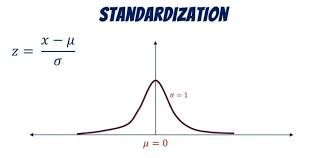


In [12]:
mean = np.mean(selected_data, axis=0)
std = np.std(selected_data, axis=0)

standardised_data = (selected_data - mean) / std
standardised_data[:6]
print("Means:", np.mean(standardised_data, axis=0))
print("Standard deviations:", np.std(standardised_data, axis=0))

Means: [-5.98099946e-17  2.39239978e-17 -7.41643933e-16  9.56959913e-17
  1.01676991e-16  3.46897969e-16 -1.07657990e-16  1.19619989e-17
 -5.68194949e-16 -2.39239978e-16  1.37562988e-16 -1.46534487e-16]
Standard deviations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [13]:
n= standardised_data.shape[0]
cov_matrix = (standardised_data.T @ standardised_data) / (n-1)
cov_matrix

array([[ 1.00168634,  0.28899539,  0.24544679,  0.38713922, -0.24545029,
         0.30961969, -0.36891253, -0.31348426, -0.39901543, -0.44098387,
        -0.37580098, -0.42594845],
       [ 0.28899539,  1.00168634,  0.21333737,  0.24023442, -0.21334606,
         0.25243049, -0.23244903, -0.18060952, -0.16759034, -0.17510584,
        -0.11434487, -0.20858905],
       [ 0.24544679,  0.21333737,  1.00168634,  0.6527522 , -1.00168633,
         0.22866807, -0.6262459 , -0.27439309, -0.26699267, -0.51359092,
        -0.26661431, -0.44049159],
       [ 0.38713922,  0.24023442,  0.6527522 ,  1.00168634, -0.6527523 ,
         0.33022238, -0.59193849, -0.40540788, -0.39962352, -0.51458269,
        -0.38221811, -0.441068  ],
       [-0.24545029, -0.21334606, -1.00168633, -0.6527523 ,  1.00168634,
        -0.22867207,  0.62624836,  0.27439493,  0.26699783,  0.51359345,
         0.26661723,  0.4404946 ],
       [ 0.30961969,  0.25243049,  0.22866807,  0.33022238, -0.22867207,
         1.00168634, -

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The covariance matrix helps us see how different feautures in our dataset are connected.For example, it can show whether malaria cases change together with things like population, access to clean water, or sanitation. We also need it because PCA uses these relationships to find where most of the important differences in the data are. This helps us reduce the number of features while keeping as much useful information as possible.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = None  # Perform eigendecomposition
eigenvalues, eigenvectors

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = None  # Sort eigenvalues in descending order
sorted_eigenvectors = None  # Sort eigenvectors accordingly
sorted_eigenvectors

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA


# Plot original data (first two features for simplicity)


# Plot reduced data after PCA


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
